# **Project Title**

COVID-19 Trend Analysis and Prediction using Python

Capstone Project

**Author:** Aditi Singh

# **Introduction**

COVID-19 had a major impact across the world. Analyzing the trends of confirmed cases, recoveries, and deaths can help understand how the disease spreads and how quickly patients recover.

In this project, we analyze global and Indian COVID-19 data using Python. We visualize trends using Plotly and build a time-series forecasting model using Facebook Prophet to predict future cases.

# **Objective**

• Analyze COVID-19 confirmed, recovered, and death cases

• Visualize trends across countries and regions

• Understand infection and recovery patterns


• Forecast the number of cases for the upcoming week

# **Data Description**

 The dataset contains information about:

* Confirmed cases

* Death cases

* Recovered cases

* Country and region information

* Date-wise COVID statistics

# **Tools & Libraries**

Pandas → Data manipulation

NumPy → Numerical operations

Plotly → Interactive visualization

Prophet → Time series forecasting

Matplotlib → Basic plotting

# **Import Libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **Data Loading**

In [4]:
df = pd.read_csv('/content/covid_19_clean_complete.csv')
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


# **Data Cleaning**

In [14]:
df.shape

(49068, 10)

In [7]:
df.head(40)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.060800,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.416100,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.069100,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.473500,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.868800,151.209300,2020-01-22,0,0,0,0,Western Pacific


After examining `df.head(40)`, I noticed that many values in the Province/State column are null. This happens because some countries report data at the country level, while others report data at the state or province level.

For instance, Australia appears multiple times since its data is divided into provinces such as New South Wales and Queensland. Therefore, to perform country-level analysis correctly, we need to group the data by the Country/Region column to aggregate all provinces belonging to the same country.

After exploring the dataset structure, I will now focus on analyzing the COVID-19 data for India. Since India appears as a single country entry in the dataset, filtering the data by the Country/Region column allows us to analyze the trend of cases specifically for India.

In [12]:
df[df["Country/Region"]=="India"]

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia
...,...,...,...,...,...,...,...,...,...,...
47892,NaN,India,20.593684,78.96288,2020-07-23,1288108,30601,817209,440298,South-East Asia
48153,NaN,India,20.593684,78.96288,2020-07-24,1337024,31358,849432,456234,South-East Asia
48414,NaN,India,20.593684,78.96288,2020-07-25,1385635,32060,885573,468002,South-East Asia
48675,NaN,India,20.593684,78.96288,2020-07-26,1435616,32771,917568,485277,South-East Asia


# **EDA**

In [15]:
df.Date.value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


The dataset includes 188 days of time-series data, starting from 22 January and ending on 27 July, which allows us to analyze the progression of COVID-19 cases over this period.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


After examining the dataset using `df.info()`, I noticed that the Date column is stored as an object type instead of datetime. Since time-series analysis requires datetime format, I will convert this column to datetime using pandas.

In [17]:
df['Date']=pd.to_datetime(df['Date'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [19]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


Since some countries have data reported at the state or province level, the dataset is aggregated by country and date to consolidate multiple state-level entries into a single country-level record for each day.

In [20]:
top=df[df["Date"]=="2020-01-22"]
top.head(60)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.060800,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.416100,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.069100,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.473500,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.868800,151.209300,2020-01-22,0,0,0,0,Western Pacific


In [21]:
top.groupby(by="Country/Region")[["Confirmed","Deaths","Recovered","Active"]].sum().reset_index()

,Country/Region,Confirmed,Deaths,Recovered,Active
0,Afghanistan,0,0,0,0
1,Albania,0,0,0,0
2,Algeria,0,0,0,0
3,Andorra,0,0,0,0
4,Angola,0,0,0,0
...,...,...,...,...,...
182,West Bank and Gaza,0,0,0,0
183,Western Sahara,0,0,0,0
184,Yemen,0,0,0,0
185,Zambia,0,0,0,0


In [22]:
df=df.groupby(by=["Date","Country/Region"])[["Confirmed","Deaths","Recovered","Active",]].sum().reset_index()
df

,Date,Country/Region,Confirmed,Deaths,Recovered,Active
0,2020-01-22,Afghanistan,0,0,0,0
1,2020-01-22,Albania,0,0,0,0
2,2020-01-22,Algeria,0,0,0,0
3,2020-01-22,Andorra,0,0,0,0
4,2020-01-22,Angola,0,0,0,0
...,...,...,...,...,...,...
35151,2020-07-27,West Bank and Gaza,10621,78,3752,6791
35152,2020-07-27,Western Sahara,10,1,8,1
35153,2020-07-27,Yemen,1691,483,833,375
35154,2020-07-27,Zambia,4552,140,2815,1597


A new DataFrame is created after aggregating the data by country, combining all state or province-level records.

Calculate the total number of Confirmed, Death, Recovered, and Active cases across all 187 countries for each specific date.

In [23]:
confirmed=df.groupby(by="Date")["Confirmed"].sum().reset_index()
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


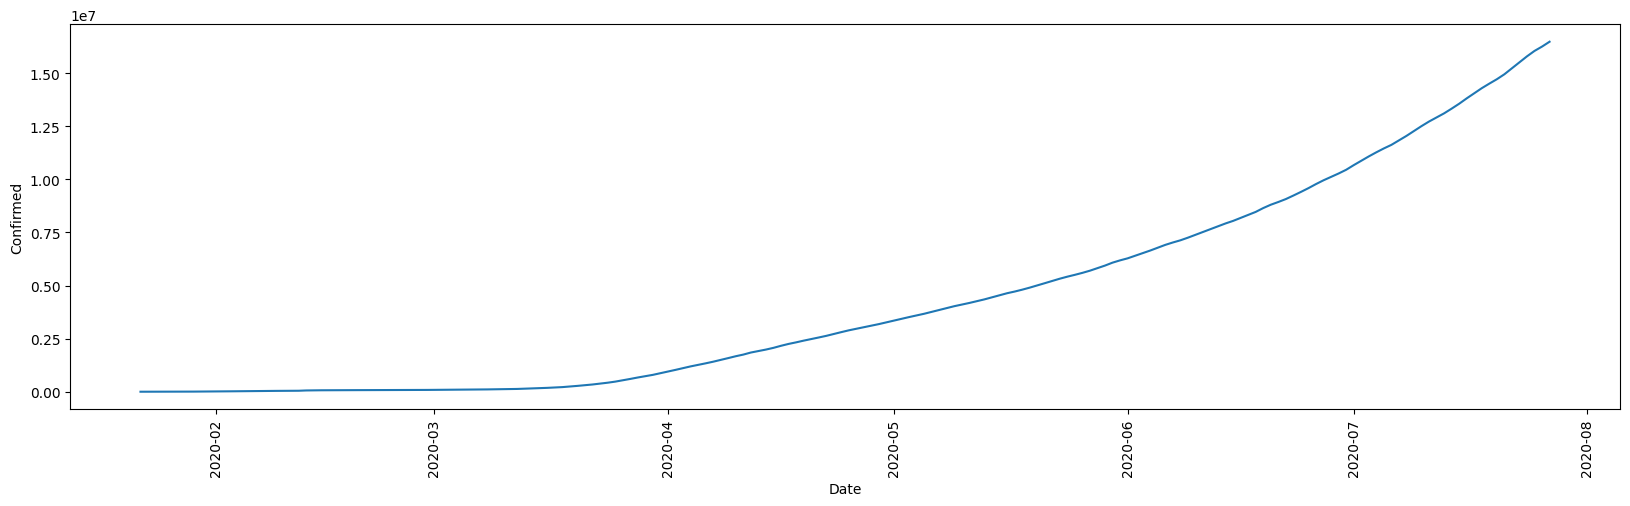

In [24]:
plt.figure(figsize=(20,5))
sns.lineplot(data=confirmed , x="Date", y="Confirmed")
plt.xticks(rotation=90)
plt.show()

In [25]:
Active=df.groupby(by="Date")["Active"].sum().reset_index()
Active

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


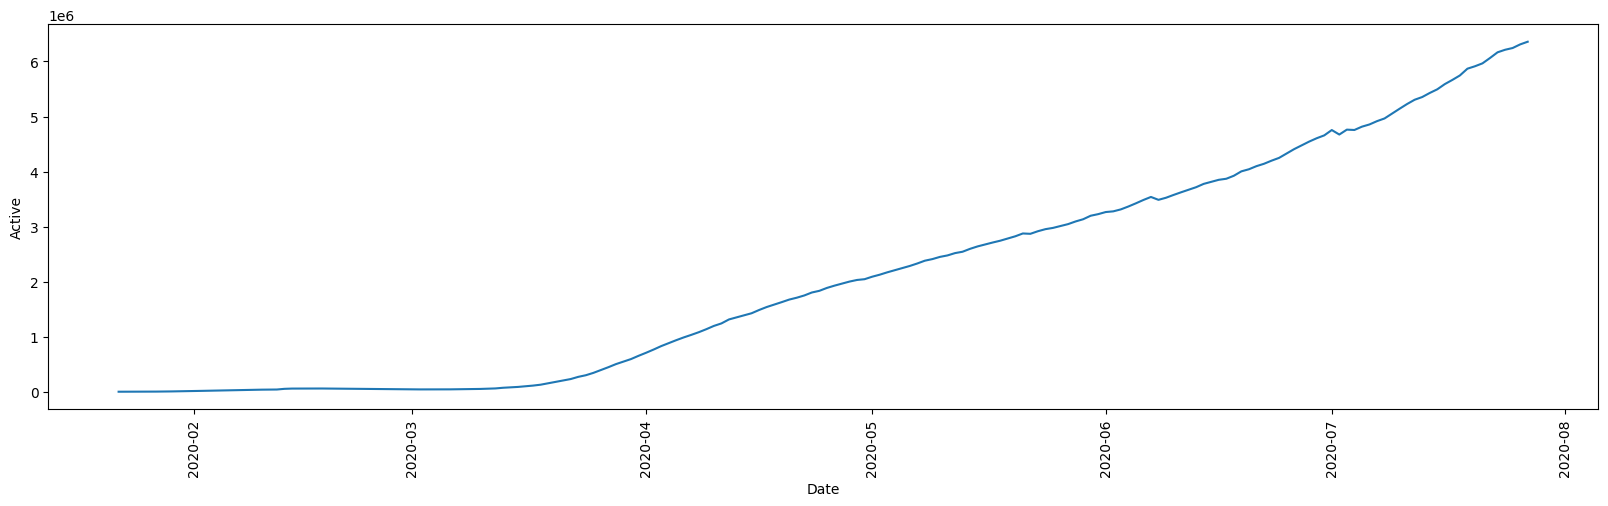

In [26]:
plt.figure(figsize=(20,5))
sns.lineplot(data=Active , x="Date", y="Active")
plt.xticks(rotation=90)
plt.show()

In [27]:
Deaths=df.groupby(by="Date")["Deaths"].sum().reset_index()
Deaths

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


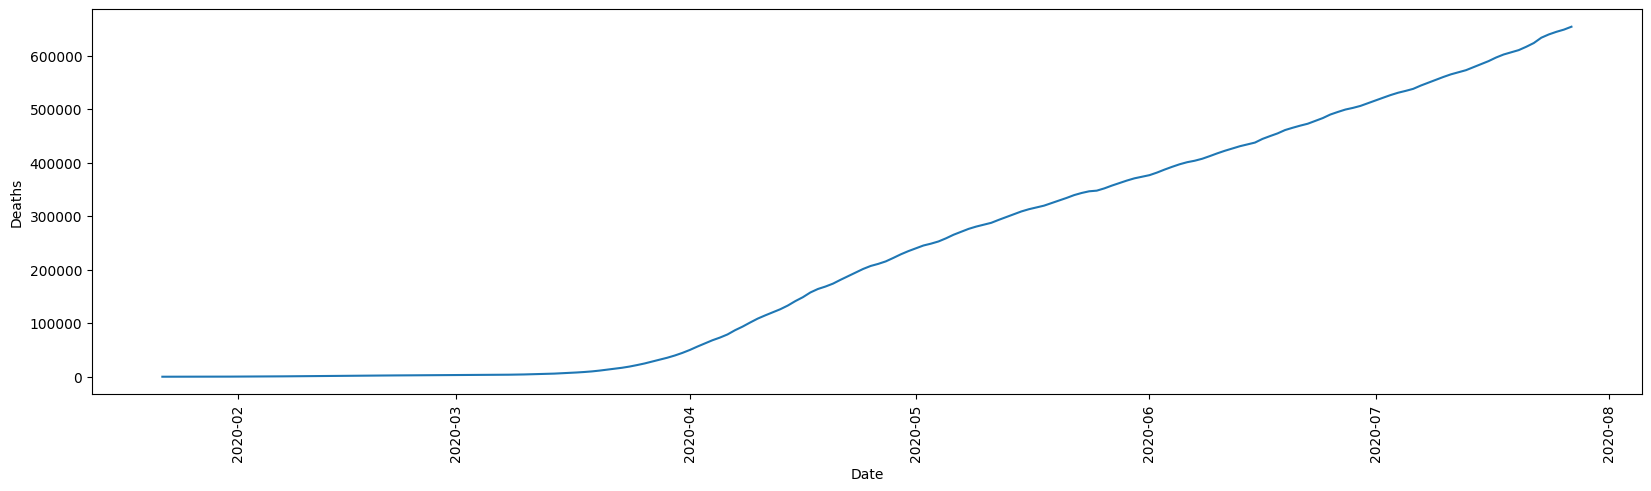

In [28]:
plt.figure(figsize=(20,5))
sns.lineplot(data=Deaths , x="Date", y="Deaths")
plt.xticks(rotation=90)
plt.show()

In [29]:
Recovered=df.groupby(by="Date")["Recovered"].sum().reset_index()
Recovered

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


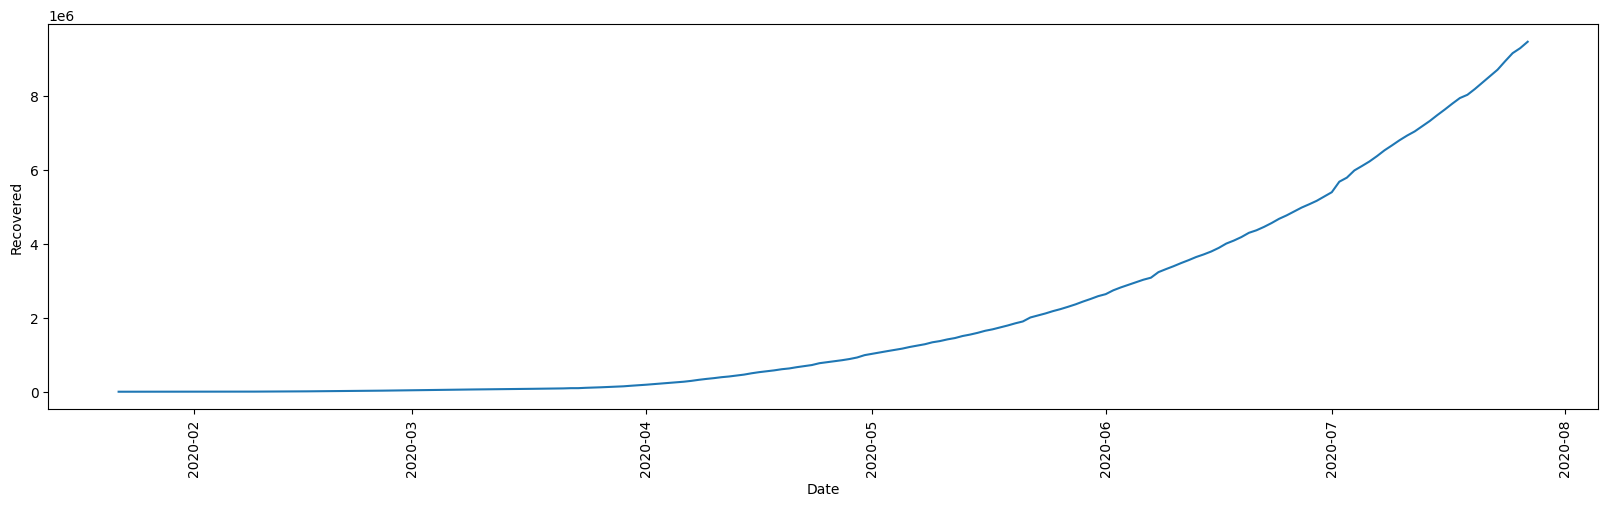

In [30]:
plt.figure(figsize=(20,5))
sns.lineplot(data=Recovered , x="Date", y="Recovered")
plt.xticks(rotation=90)
plt.show()

Identify the top 10 countries with the highest Active, Recovered, Confirmed, and Death case counts.

In [31]:
# Use Bar chart to compare
country_active = df.groupby(by='Country/Region')['Active'].sum().reset_index()
country_active

,Country/Region,Active
0,Afghanistan,1089052
1,Albania,72117
2,Algeria,345886
3,Andorra,19907
4,Angola,15011
...,...,...
182,West Bank and Gaza,170967
183,Western Sahara,190
184,Yemen,25694
185,Zambia,43167


In [32]:
# Sort the data in descending order
top10 = country_active.sort_values(by='Active', ascending=False).head(10)
top10

,Country/Region,Active
173,US,156981121
23,Brazil,31094060
177,United Kingdom,22624595
138,Russia,19668578
79,India,15987913
61,France,10980287
157,Spain,9277432
32,Canada,8656985
132,Peru,7748957
85,Italy,7363518


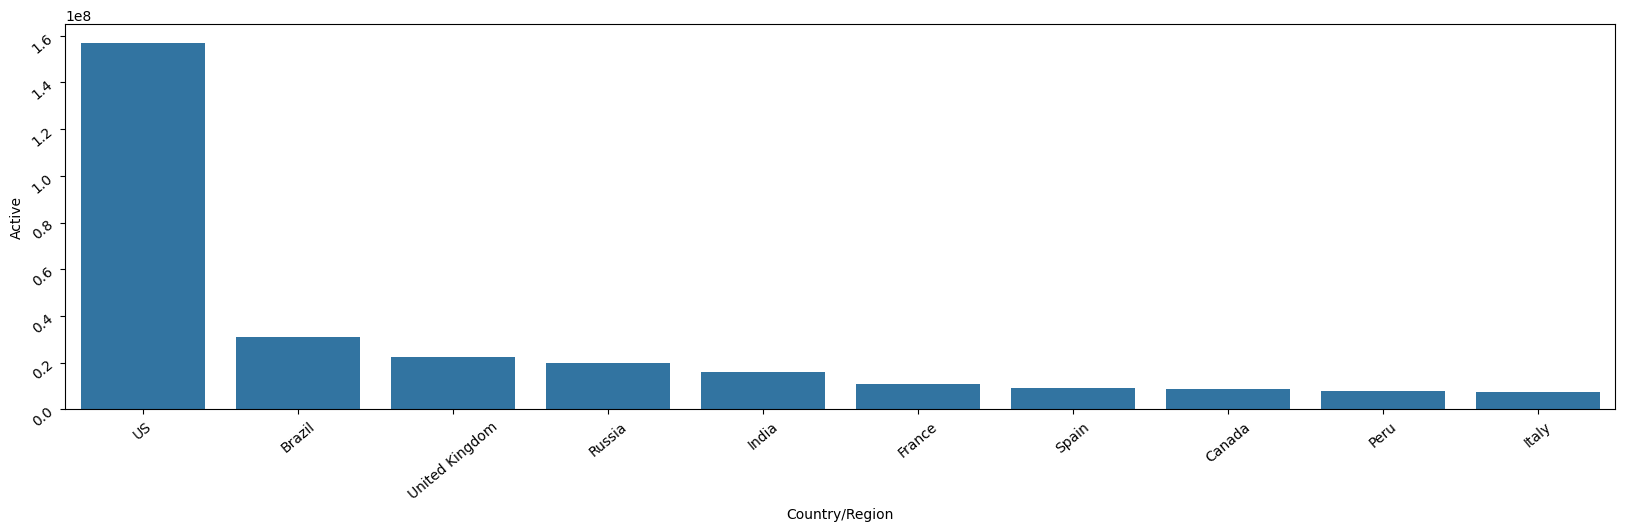

In [34]:
plt.figure(figsize=(20,5))
sns.barplot(x='Country/Region', y='Active', data=top10)
plt.xticks(rotation=40)
plt.yticks(rotation=40)
plt.show()

###Analyze and compare the death rates of India, China, and the United States across different dates.

Text(0, 0.5, 'No of Deaths')

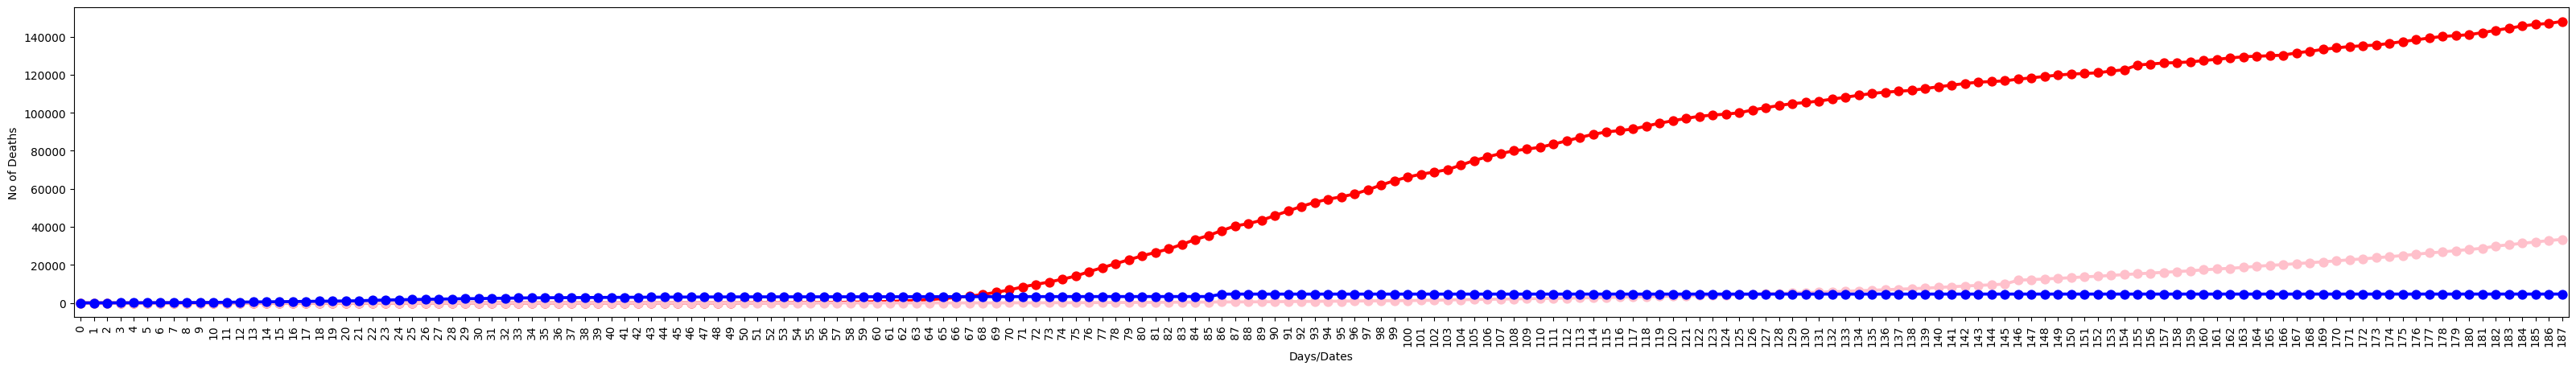

In [35]:
# India data of death
India=df[df["Country/Region"]=="India"]
India_data =India.groupby(by="Date")["Deaths"].sum().reset_index()

# US data of death
US=df[df["Country/Region"]=="US"]
US_data =US.groupby(by="Date")["Deaths"].sum().reset_index()

# China data of death
China=df[df["Country/Region"]=="China"]
China_data =China.groupby(by="Date")["Deaths"].sum().reset_index()

plt.figure(figsize=(40,5))

# Pointplot 3 times to plot all 3 country death data together
sns.pointplot(x=US_data.index , y=US_data.Deaths , color="Red")
sns.pointplot(x=India_data.index , y=India_data.Deaths , color="Pink")
sns.pointplot(x=China_data.index , y=China_data.Deaths , color="Blue")

plt.xlabel("Days/Dates")
plt.xticks(rotation=90)
plt.ylabel("No of Deaths")

# Use a time series model to forecast the future values of Death, Active, Recovered, and Confirmed cases.

In [36]:
confirmed  # 22nd Jan to 27th July
confirmed.columns=["ds","y"]
confirmed

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [37]:
from prophet import Prophet
fb_prophet_model = Prophet()

In [38]:
# Train the model
fb_prophet_model.fit(confirmed)  # Directly pass your data

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [39]:
# Making forecasting for next 15 days after 27th July 2020 till 11 August 2020
future = fb_prophet_model.make_future_dataframe(periods=15)  # Period means for next how many days
forecast_values = fb_prophet_model.predict(future)
forecast_values.tail(18)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
185,2020-07-25,1.572508e+07,1.563249e+07,1.583942e+07,1.572508e+07,1.572508e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.573883e+07
186,2020-07-26,1.592907e+07,1.582620e+07,1.604635e+07,1.592907e+07,1.592907e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.593637e+07
187,2020-07-27,1.613306e+07,1.602194e+07,1.623481e+07,1.613306e+07,1.613306e+07,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,0.0,0.0,0.0,1.613096e+07
188,2020-07-28,1.633705e+07,1.621199e+07,1.643237e+07,1.633705e+07,1.633705e+07,-16846.239961,-16846.239961,-16846.239961,-16846.239961,-16846.239961,-16846.239961,0.0,0.0,0.0,1.632021e+07
189,2020-07-29,1.654104e+07,1.642390e+07,1.663135e+07,1.653968e+07,1.654323e+07,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,1.652998e+07
190,2020-07-30,1.674503e+07,1.664179e+07,1.685271e+07,1.673910e+07,1.675153e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685259e+07,1.706258e+07,1.693727e+07,1.696127e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.706229e+07,1.727733e+07,1.713349e+07,1.717407e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.724450e+07,1.747560e+07,1.732767e+07,1.738500e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07
194,2020-08-03,1.756100e+07,1.744991e+07,1.767608e+07,1.752119e+07,1.760038e+07,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,0.0,0.0,0.0,1.755889e+07


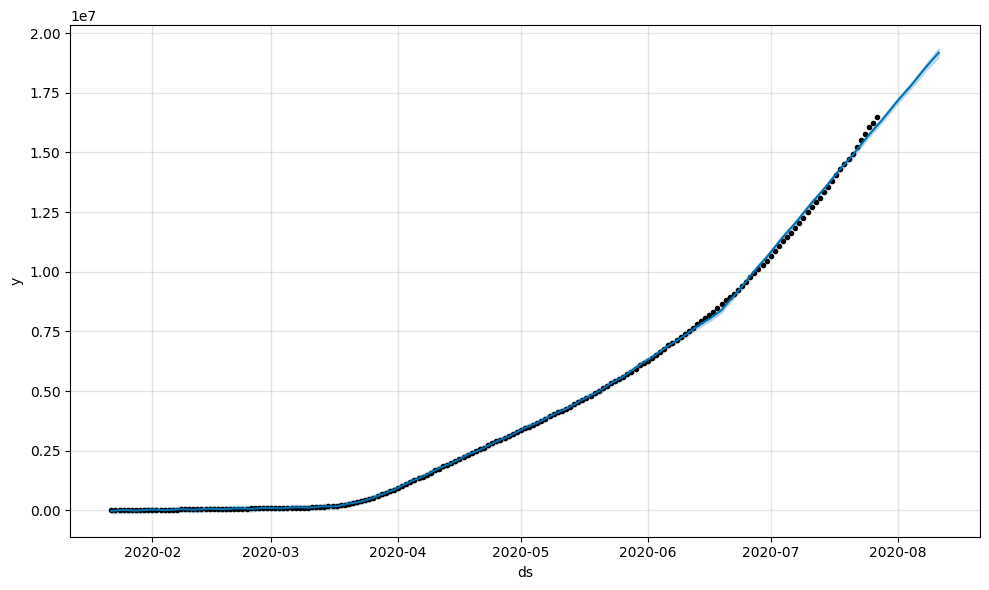

In [40]:
forecast_values[['ds','yhat','yhat_upper','yhat_lower']]
'''
ds:
This column contains the dates for which the predictions have been made. It stands for "date stamp."

yhat:
This is the predicted value (forecast) for the given date in the ds column. It represents the model's best estimate for that point in time.

yhat_upper:
This column represents the upper bound of the predicted value, which indicates the higher end of the confidence interval.
It suggests that the actual value is unlikely to exceed this amount, giving you an idea of the prediction's uncertainty.

yhat_lower:
This column represents the lower bound of the predicted value, indicating the lower end of the confidence interval. It suggests that the actual value is unlikely to be lower than this amount.
'''
fb_prophet_model.plot(forecast_values)
plt.show()

In [41]:
import plotly
import plotly.express as px

In [42]:
world_data = df.groupby(by="Country/Region")[["Confirmed" ,"Active" , "Deaths" ,"Recovered"]].sum().reset_index()
world_data

,Country/Region,Confirmed,Active,Deaths,Recovered
0,Afghanistan,1936390,1089052,49098,798240
1,Albania,196702,72117,5708,118877
2,Algeria,1179755,345886,77972,755897
3,Andorra,94404,19907,5423,69074
4,Angola,22662,15011,1078,6573
...,...,...,...,...,...
182,West Bank and Gaza,233461,170967,1370,61124
183,Western Sahara,901,190,63,648
184,Yemen,67180,25694,17707,23779
185,Zambia,129421,43167,2643,83611


In [44]:
figure= px.choropleth(world_data , locations="Country/Region" ,locationmode="country names" , color="Active",
                      hover_name="Country/Region",title="Countries with most Active cases")
figure.show()

# **RESULT**

Infection rate increased rapidly in early months

Recovery rate improved with time

Prediction shows moderate growth in upcoming week

# **CONCLUSION**

This project analyzed COVID-19 trends using Python and visualized global patterns of infection and recovery. Time-series forecasting was applied to predict future case trends, which can help understand the possible spread of the virus.